## A mixed integer linear programming approach for the design of chemical process families

In this small example, we will use a transcritical $\text{CO}_2$ refrigeration system with four unit modules. 

We have the following problem specifications:

- We aim to design a family of 56 process variants ($|V|=56$) where each variant $v \in V$ is described by its maximum outside air temperature $T^{\text{max}}_v$ and required capacity $C^{\text{min}}_v$. 

- Additionally, we aim to design the evaporator area, compressor area, and compressor design flow commonly as apart of the process platform $\mathcal{P}$. 

- We can select 2 out of 10 possible evaporator areas, 2 out of 14 possible condender areas, and 2 out of 10 possible compressor design flows.

- This indicates the data (data/transcritical-co2-data.csv) should consist of $56 \times 10 \times 14 \times 10 = 78,400$ data points; which, indeed, it does.

In this notebook, we will use the discretized formulation, solving a MILP directly with the data provided.

To learn more about the problem formulation and process family design in general, refer to the following publication.

> Stinchfield, Georgia, Joshua C. Morgan, Sakshi Naik, Lorenz T. Biegler, John C. Eslick, Clas Jacobson, David C. Miller et al. "A mixed integer linear programming approach for the design of chemical process families." Computers & Chemical Engineering 183 (2024): 108620.

In [13]:
import os
from process_family.type.discretized import DiscretizedProcessFamily
from process_family.utils.parameters.base import Parameters

### Data Preparation & Initialization

Given the dataset described above, the process_family package will organize the data into the necessary sets and perform minor preprocessing tasks to prepare the data. 

We need to specify the following information, which should be initialized within the Parameters object offer within the process_family package:

- string path to the data file.
- list of string names of columns corresponding to the process variant descriptions (in this case, it is the columns corresponding to $T^{\text{max}}_v$ and $C^{\text{min}}_v$).
- list of string names of columns corresponding to the common unit module design elements (in this case, it is the columns corresponding to the evaporator area, condenser area, and compressor design flow).
- string name of column with True/False entries indicating if a particular simulation (or optimization) of a variant $v \in V$ with a given set of common unit module designs was successfully solved or not; in another sense, this is the feasibility.
- string name of column corresponding to the total annualized cost of a particular variant $v \in V$ with a particular set of common unit module designs.
- dictionary, where the keys are the string names of the columns corresponding to the common unit module design elements and the values correspond to the total (integer) number of each common design we can select (i.e., for the evaporator area, this would be 2 because we only want to select 2 of the 10 considered).
- dictionary, where the keys are the string names of the columns corresponding to the common unit module design elements and the values correspond to a list of labels used for identifying the common unit module designs selected within the platform $\mathcal{P}$.

In [14]:
# initialize parameters
params = Parameters("transcritical-co2")

# init path to csv file with transcritical co2 data
params.csv_filepath=os.path.join(params.cwd,"data/transcritical-co2-data.csv")

# (1) factors defining each process variant (must match with .csv file names)
params.process_variant_columns=[
                            "Capacity", 
                            "Outside Air Temperature"
                        ]

# (2) common unit module types (must match with .csv file names)
params.common_unit_types_column=[
                            "Evaporator Area",
                            "Condenser Area",
                            "Compressor Design Flow"
                        ]

# (3) col. of .csv file that corresponds to the "success" of each simulation
params.feasibility_column=["Success"]

# (4) col. of .csv file that corresponds to the total annualized cost of each simulation
params.annualized_cost_column=["Total Annualized Cost"]

# (5) max. num of designs offered for each common unit module type
#     one key per entry in common_unit_module_types
params.num_common_unit_type_designs={
                                "Evaporator Area":2,
                                "Condenser Area":2,
                                "Compressor Design Flow":2
                            }

# define the labels for each of the common unit type designs allowable.
params.labels_for_common_unit_module_designs ={
                                            "Evaporator Area": range(2),
                                            "Condenser Area": range(2),
                                            "Compressor Design Flow": range(2) 
                                        }

# renaming, if we wish, for when we output results summarys/plots
params.process_variant_column_names = ["Capacity (tons)", 
                                        "Max. Outside Air Temperature (deg. C)"]
params.common_module_type_column_names = ["Evap. Area ($m^2$)",
                                        "Cond. Area ($m^2$)",
                                        "Compr. Flow (mol./s)"]
params.make_results_dir("discretized")

### Optimization

Given all if this necessary information, the process_family package builds the discretized model and solves it for you!

In [15]:
# using Gurobi by default - if you would like to change this,
# send appropriate string name argument when invoking solve_model()
from pyomo.opt import SolverFactory
assert SolverFactory("gurobi").available()

In [16]:
# initializes all sets
dpfd = DiscretizedProcessFamily(params)

# build & solve model
dpfd.build_model()
dpfd.solve_model()

total number of costs = 78400
total number of unique costs = 4513


['Evaporator Area', 'Condenser Area', 'Compressor Design Flow']
dict_keys(['Evaporator Area', 'Condenser Area', 'Compressor Design Flow'])
Set parameter Username
Set parameter LicenseID to value 2649923
Academic license - for non-commercial use only - expires 2026-04-10
Read LP format model from file /var/folders/44/14_qr9yx01zcg633lzkm1nt80000gn/T/tmpbx5z484l.pyomo.lp
Reading time = 0.09 seconds
x1: 116183 rows, 38742 columns, 270990 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.3.0 24D70)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 116183 rows, 38742 columns and 270990 nonzeros
Model fingerprint: 0x62ec6b3b
Variable types: 38708 continuous, 34 integer (34 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+04, 4e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range      

And that's it! There is also basic capabilities, assuming low enough dimensions, for plotting and generating a summary of results text file.

/Users/gcstinchfield/main/dev/idaes-mvo/process_family/type/base.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


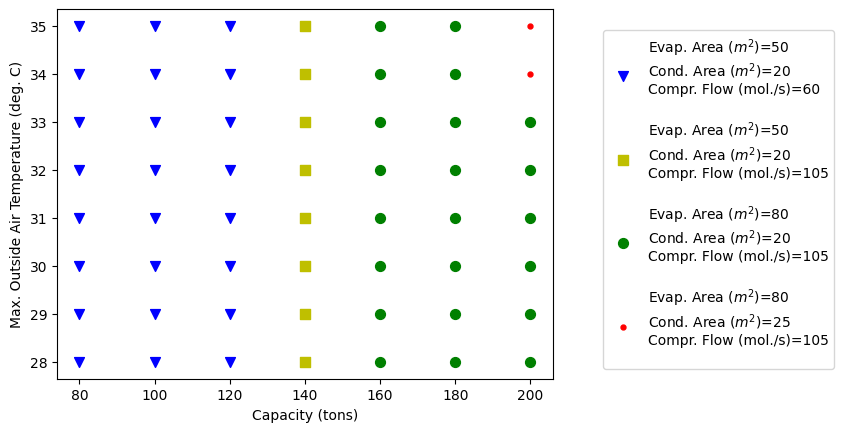

In [17]:
# plot results
dpfd.plot(directory = os.path.join(params.results_dir, "discretized-results.png"),
          process_variant_column_names = params.process_variant_column_names,
          common_module_type_columns = params.common_module_type_column_names,
          show = True)

In [18]:
# create results summary, store in results_pathstring
dpfd.results_summary(directory = os.path.join(params.results_dir, "discretized-results.txt"))



Variant:
	 Capacity = 80
	 Outside Air Temperature = 28
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Design Flow = 60

Variant:
	 Capacity = 80
	 Outside Air Temperature = 29
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Design Flow = 60

Variant:
	 Capacity = 80
	 Outside Air Temperature = 30
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Design Flow = 60

Variant:
	 Capacity = 80
	 Outside Air Temperature = 31
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Design Flow = 60

Variant:
	 Capacity = 80
	 Outside Air Temperature = 32
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Design Flow = 60

Variant:
	 Capacity = 80
	 Outside Air Temperature = 33
Common Unit Module Designs Selected:
	 Evaporator Area = 50
	 Condenser Area = 20
	 Compressor Des

In [19]:
from datetime import datetime
print("Notebook last run on:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Notebook last run on: 2025-06-16 18:39:01
